**Project goal**:

Predict loan approval using applicant data.

**Business value**
- Faster decisions
- Lower default risk
- Clear interview story

**Dataset**

Use the common Loan Prediction dataset from analytics practice platforms.

**Target**

Loan_Status

Y approved

N rejected


**Tech stack**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

**Step 1. Import libraries**

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

**Step 2. Load data**

In [71]:
# Load dataset
data = pd.read_csv("Loan-Approval-Prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Step 3. Basic checks**

In [72]:
data.shape
data.info()
data.isnull().sum()
# Drop ID column
data.drop("Loan_ID", axis=1, inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


**Step 4. Data cleaning**

Fill missing values

In [73]:
# Handle missing values
categorical_cols = ["Gender", "Married", "Dependents", "Self_Employed"]
numerical_cols = ["LoanAmount", "Loan_Amount_Term", "Credit_History"]

for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

for col in numerical_cols:
    data[col] = data[col].fillna(data[col].median())

**Step 5. Exploratory Data Analysis**

Credit history vs approval


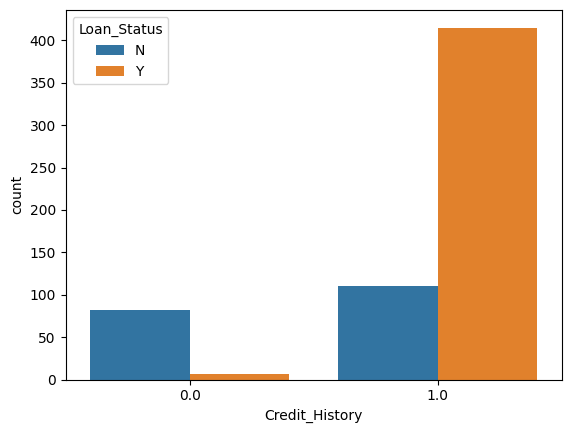

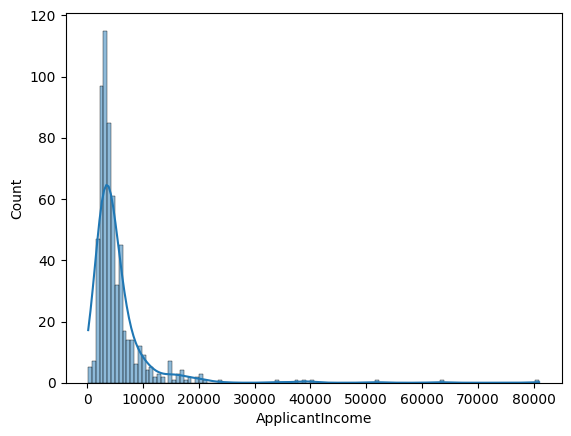

In [74]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=data)
plt.show()
#Income distribution.
sns.histplot(data['ApplicantIncome'], kde=True)
plt.show()


**Step 6. Feature engineering**

Create total income.

In [75]:
# -------------------- Feature Engineering --------------------
data["TotalIncome"] = data["ApplicantIncome"] + data["CoapplicantIncome"]
data["LoanAmount_log"] = np.log(data["LoanAmount"])

data.drop(["ApplicantIncome", "CoapplicantIncome", "LoanAmount"], axis=1, inplace=True)


**Step 7. Encode categorical variables**

In [76]:
# One-Hot Encoding
data = pd.get_dummies(data, drop_first=True)

**Step 8. Split features and target**

In [77]:
# Split features and target
X = data.drop("Loan_Status_Y", axis=1)
y = data["Loan_Status_Y"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Step 9. Build model**

In [78]:
# -------------------- Models --------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42)
}

results = []


**Step 10. Evaluation**

In [79]:
# Evaluation


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.837398   0.882353  0.882353  0.882353  0.855418
1        Random Forest  0.837398   0.857143  0.917647  0.886364  0.830031
2    Gradient Boosting  0.837398   0.842105  0.941176  0.888889  0.820124
3                  SVM  0.813008   0.836957  0.905882  0.870056  0.796904


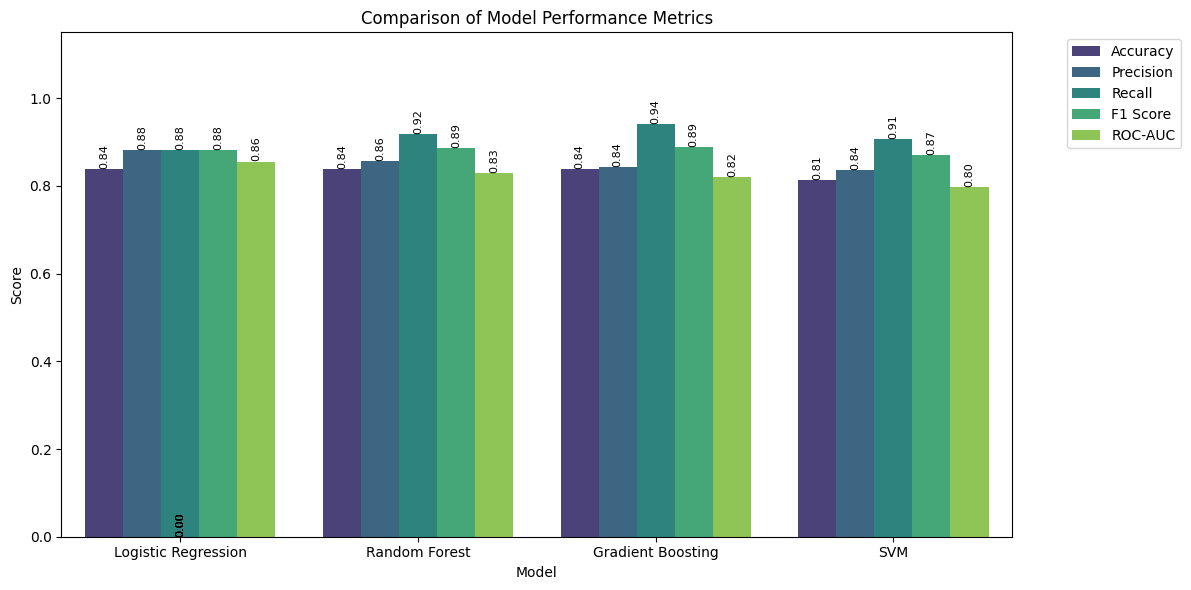

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create the dataframe
data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM'],
    'Accuracy': [0.837398, 0.837398, 0.837398, 0.813008],
    'Precision': [0.882353, 0.857143, 0.842105, 0.836957],
    'Recall': [0.882353, 0.917647, 0.941176, 0.905882],
    'F1 Score': [0.882353, 0.886364, 0.888889, 0.870056],
    'ROC-AUC': [0.855418, 0.830031, 0.820124, 0.796904]
}

df = pd.DataFrame(data)

# Melt the DataFrame for easy plotting with seaborn
# This transforms the data from wide format to long format
df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Set the figure size
plt.figure(figsize=(12, 6))

# Create the grouped bar chart
# hue='Metric' separates the bars by metric type
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

# Add labels and title
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1.15)  # Set y-axis limit higher to accommodate values

# Place the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add numeric values on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points',
                       fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

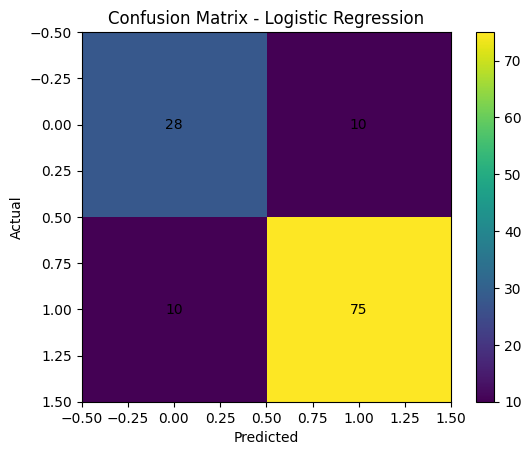

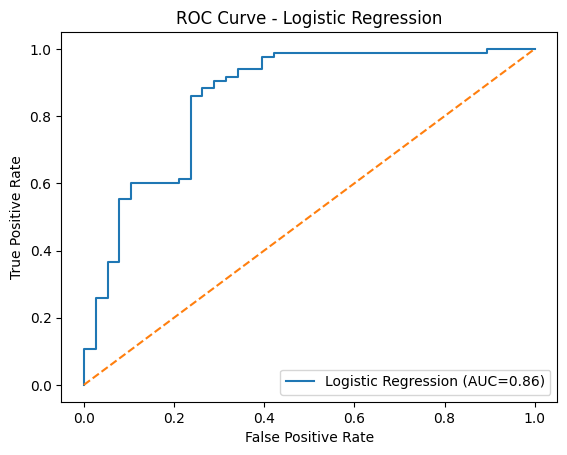

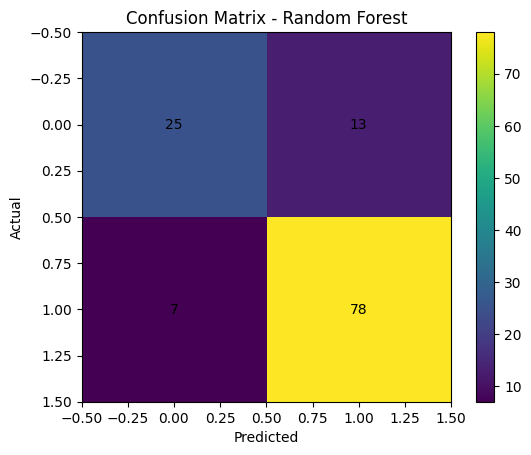

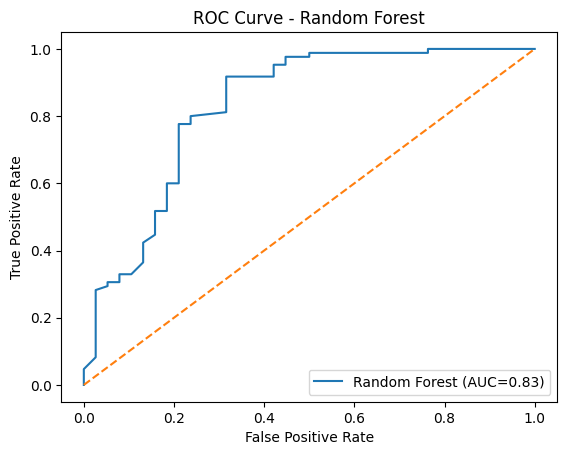

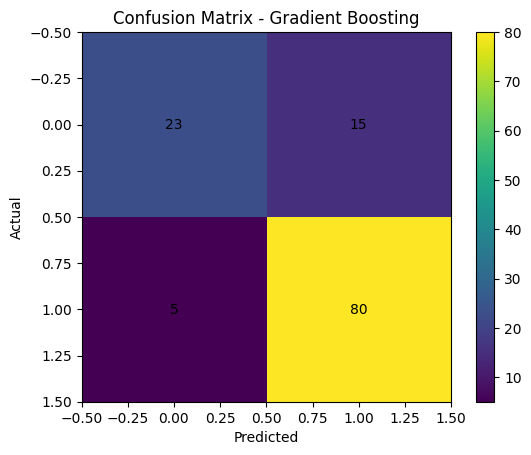

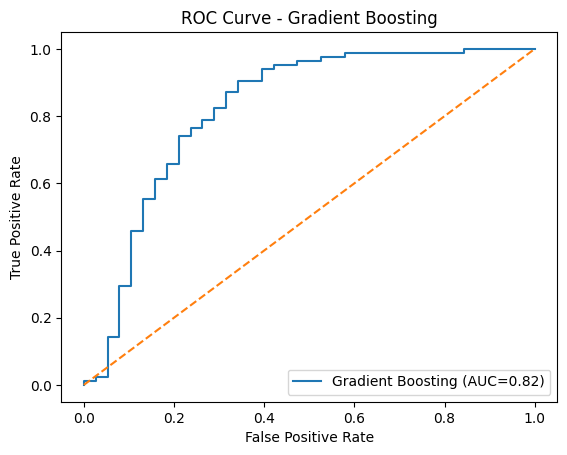

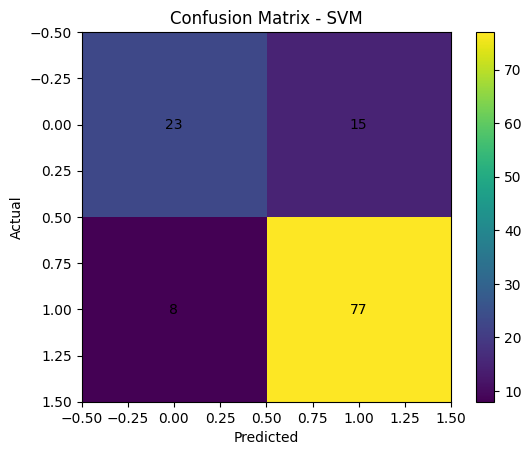

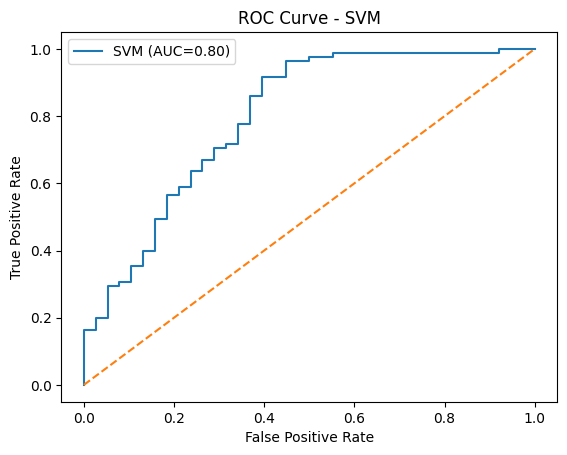

In [83]:
# -------------------- Training + Evaluation --------------------
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_prob):.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()


In [84]:
# -------------------- Hyperparameter Tuning --------------------
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [85]:
# -------------------- Tuned Model Evaluation --------------------
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nBest Random Forest Parameters:")
print(grid.best_params_)

print("\nTuned Random Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Best Random Forest Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Random Forest Performance:
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1 Score: 0.9081081081081082
ROC-AUC: 0.848297213622291


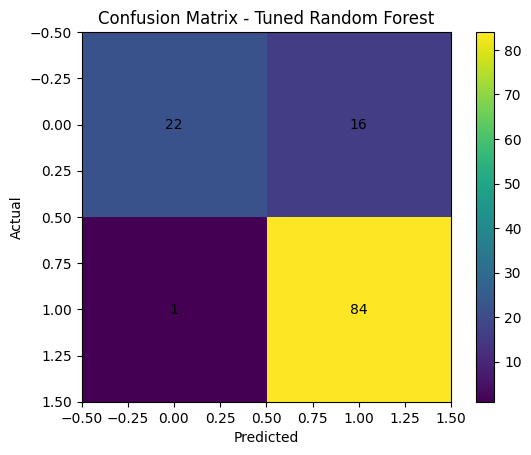

In [86]:
# Confusion Matrix (Tuned RF)
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

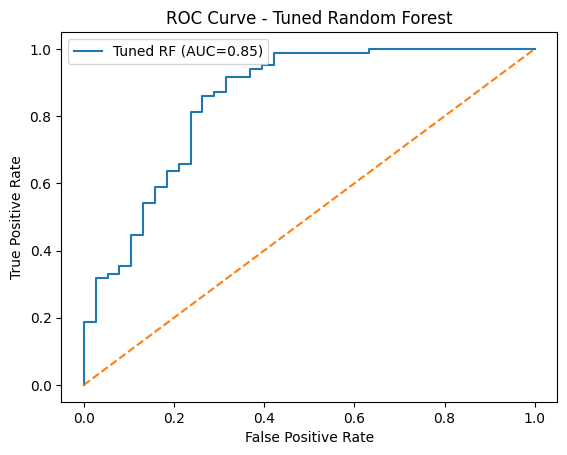

In [87]:
# ROC Curve (Tuned RF)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"Tuned RF (AUC={roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.show()
